In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
#1A.NUMERICAL vs CATEGORICAL COLUMNS
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('Numerical:', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
Numerical: ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [9]:
#1B.WHICH STATISTIC FITS WHICH TYPE
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


#### 🧪 LAB EXERCISE 1 — Classify the columns

1. Print the list of **numerical** columns and the list of **categorical** columns.
2. For a numerical column (e.g. `tip`), print its **mean**.
3. For a categorical column (e.g. `sex`), print its **value counts**.

In [10]:
# 1. Numerical vs categorical columns
# YOUR CODE HERE
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('Numerical:', numerical)
print('Categorical:', categorical)

# 2. Mean of a numerical column (tip)
# YOUR CODE HERE
print('Mean tip:', round(df['tip'].mean(), 2))

# 3. Value counts of a categorical column (sex)
# YOUR CODE HERE
print('sex value counts:')
print(df['sex'].value_counts())

Numerical: ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean tip: 3.0
sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
# 2A. MEAN, MEDIAN, MODE
col = df['total_bill']
print('Mean :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode :', round(col.mode()[0], 2))

Mean : 19.79
Median : 17.8
Mode : 13.42


mean > median ? True -> right-skewed


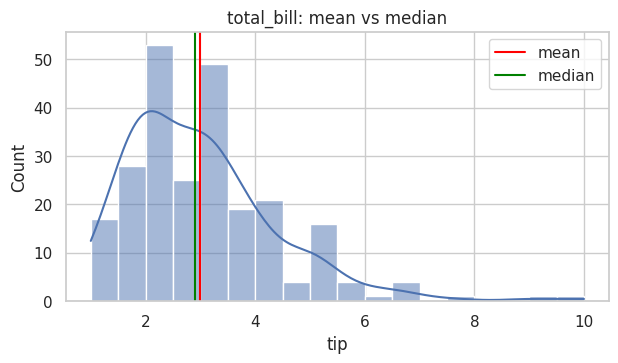

In [29]:
#2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend();
plt.title('total_bill: mean vs median');
plt.show()

#### 🧪 LAB EXERCISE 2 — Central tendency

For the **`tip`** column:
1. Print its mean, median and mode.
2. Is it right-skewed? Check whether `mean > median`.
3. Plot a histogram of `tip` with vertical lines at the mean and median.

Mean : 3.0
Median : 2.9
Mode : 2.0
mean > median ? True -> right-skewed


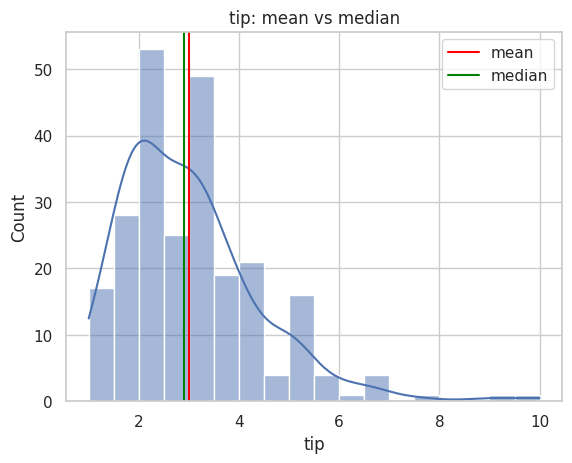

In [12]:
tip = df['tip']
# 1. mean, median, mode
# YOUR CODE HERE
print('Mean :', round(tip.mean(), 2))
print('Median :', round(tip.median(), 2))
print('Mode :', round(tip.mode()[0], 2))
# 2. mean > median ?
# YOUR CODE HERE
print('mean > median ?', tip.mean() > tip.median(), '-> right-skewed')
# 3. histogram with mean & median lines (reuse the pattern from 2B)
# YOUR CODE HERE
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(),color='red',label='mean')
plt.axvline(tip.median(),color='green',label='median')
plt.legend();
plt.title('tip: mean vs median');
plt.show()

In [13]:
#3A. RANGE, VARIANCE, STANDARD DEVIATION
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [30]:
#3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56 -> spread of the middle 50% (robust to outliers)


#### 🧪 LAB EXERCISE 3 — Spread

For the **`tip`** column:
1. Print the range, variance and standard deviation.
2. Compute Q1, Q3 and the **IQR**.
3. In a comment, say which measure of spread is most robust to outliers and why.

In [32]:
tip = df['tip']
# 1. range, variance, std
# YOUR CODE HERE
print('Range :', round(tip.max() - tip.min(), 2))
print('Var   :', round(tip.var(), 2))
print('Std   :', round(tip.std(), 2))
# 2. Q1, Q3, IQR
# YOUR CODE HERE
q1, q3 = tip.quantile(0.25), tip.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Range : 9.0
Var   : 1.91
Std   : 1.38
Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56 -> spread of the middle 50% (robust to outliers)


In [17]:
#4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


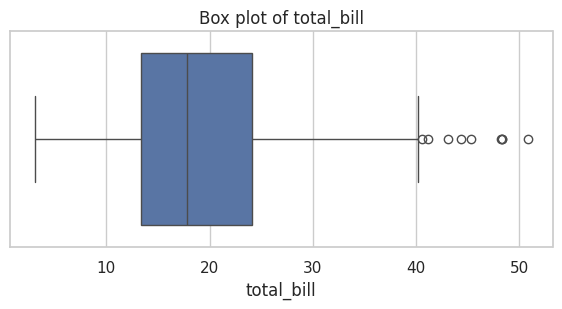

In [19]:
#BOX PLOT (a picture of the five-number summary)
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill')
plt.show()

#### 🧪 LAB EXERCISE 4 — Five-number summary & box plot

For the **`tip`** column:
1. Print its five-number summary (min, 25%, 50%, 75%, max).
2. Print its skewness and say (in a comment) which way it leans.
3. Draw a box plot of `tip`.

min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64
Skewness: 1.465


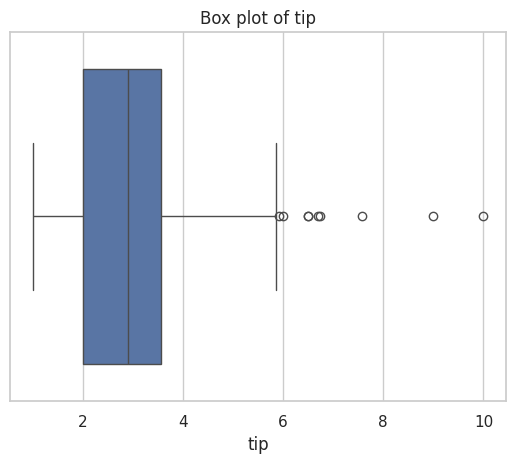

In [20]:
tip = df['tip']
# 1. five-number summary
# YOUR CODE HERE
col = df['tip']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# 2. skewness (+ comment on the direction of the lean)
# YOUR CODE HERE
print('Skewness:', round(col.skew(), 3))

# 3. box plot of tip
# YOUR CODE HERE
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip')
plt.show()

In [21]:
# 5A.CORRELATION between numerical columns
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


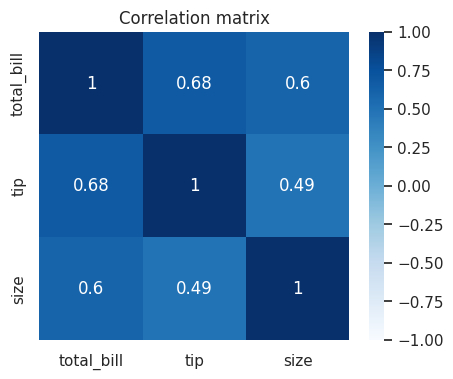

In [25]:
#5B.VISUALISE THE CORRELATION MATRIX
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix');
plt.show()

In [23]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


#### 🧪 LAB EXERCISE 5 — Correlation & full summary

1. Build the correlation matrix and print it (rounded to 2 decimals).
2. Draw a correlation **heatmap**.
3. Run `df.describe()` and, in a comment, write **3 insights** about the dataset (e.g. which column is most spread out, which pair is most correlated, any skew you notice).

Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


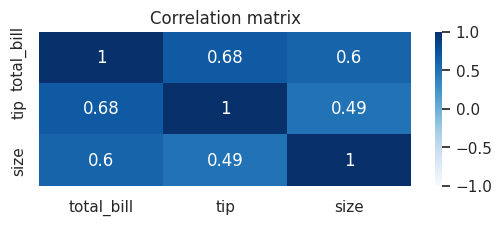

Dataset Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [36]:
# 1. correlation matrix (rounded)
# YOUR CODE HERE
corr_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr_matrix.round(2))
# 2. heatmap of the correlation matrix
# YOUR CODE HERE
plt.figure(figsize=(6,2))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix');
plt.show()
# 3. df.describe()
# YOUR CODE HERE
print("Dataset Summary:")
print(df.describe())
